In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

archivo = r"C:\Users\user\Desktop\Labo5\1_Fluidos\analisis\G\video3_brillantina_oscura_PIV.mat"

In [2]:
def leer_celda(f, results, frame, columna):
    """
    Lee una celda de resultslist de PIVlab.

    Se transpone porque MATLAB/HDF5 guarda las matrices
    con los índices intercambiados respecto de NumPy.
    """
    ref = results[frame, columna]
    return np.array(f[ref]).T

CHEQUEOS

In [3]:
with h5py.File(archivo, "r") as f:

    results = f["resultslist"]

    # Primer campo PIV: frame 0 -> frame 1
    x = leer_celda(f, results, 0, 0)
    y = leer_celda(f, results, 0, 1)

    # Campo validado por PIVlab
    u = leer_celda(f, results, 0, 6)
    v = leer_celda(f, results, 0, 7)

    tipo = leer_celda(f, results, 0, 8)


print("x:", x.shape)
print("y:", y.shape)
print("u:", u.shape)
print("v:", v.shape)

x: (30, 31)
y: (30, 31)
u: (30, 31)
v: (30, 31)


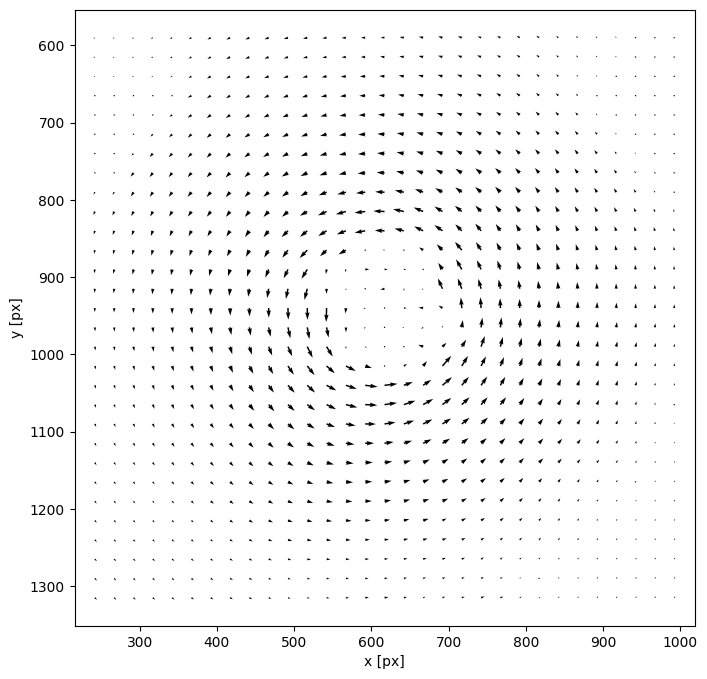

In [4]:
plt.figure(figsize=(8, 8))

plt.quiver(
    x,
    y,
    u,
    v,
    angles="xy",
    scale_units="xy",
    scale=1
)

plt.gca().invert_yaxis()
plt.axis("equal")

plt.xlabel("x [px]")
plt.ylabel("y [px]")

plt.show()

Ahora si, cargo el campo

In [5]:
with h5py.File(archivo, "r") as f:

    results = f["resultslist"]

    n_campos = results.shape[0]

    # La grilla espacial es la misma para todos los tiempos
    x = leer_celda(f, results, 0, 0)
    y = leer_celda(f, results, 0, 1)

    campos_u = []
    campos_v = []
    campos_tipo = []

    for i in range(n_campos):

        u_i = leer_celda(f, results, i, 6)
        v_i = leer_celda(f, results, i, 7)
        tipo_i = leer_celda(f, results, i, 8)

        campos_u.append(u_i)
        campos_v.append(v_i)
        campos_tipo.append(tipo_i)


u = np.stack(campos_u)
v = np.stack(campos_v)
tipo = np.stack(campos_tipo)


print("Número de campos:", n_campos)
print("u:", u.shape)
print("v:", v.shape)

Número de campos: 663
u: (663, 30, 31)
v: (663, 30, 31)


Ahora la notaicon es u[0] es el campo de 0 a 1 y u[100] es el cmapo de 100 a 101

Calibramos

In [6]:
distancia_px = 1541.98
distancia_mm = 147

dt = 16.687e-3  # s

mm_por_px = distancia_mm / distancia_px

u_mm_s = u * mm_por_px / dt
v_mm_s = v * mm_por_px / dt

x_mm = x * mm_por_px
y_mm = y * mm_por_px

print("Escala espacial:", mm_por_px, "mm/px")

Escala espacial: 0.09533197577141078 mm/px


## Determinación del centro del vórtice

In [16]:
from scipy.optimize import least_squares

U = u[0]
V = v[0]

vel = np.sqrt(U**2 + V**2)

validos = (
    np.isfinite(U)
    & np.isfinite(V)
    & np.isfinite(x)
    & np.isfinite(y)
)

# Sacamos los vectores de velocidad muy pequeña
limite = np.nanpercentile(vel[validos], 20)

usar = validos & (vel > limite)

X = x[usar]
Y = y[usar]
UU = U[usar]
VV = V[usar]
M = vel[usar]


def residuos(centro):
    xc, yc = centro

    dx = X - xc
    dy = Y - yc

    r = np.sqrt(dx**2 + dy**2)

    return (dx*UU + dy*VV) / (r*M)


# Usamos el resultado anterior como punto inicial
resultado = least_squares(
    residuos,
    x0=[xc, yc],
    loss="soft_l1"
)

xc2, yc2 = resultado.x

print("Centro robusto:")
print("xc =", xc2, "px")
print("yc =", yc2, "px")

Centro robusto:
xc = 602.3385533987949 px
yc = 946.3439368795042 px


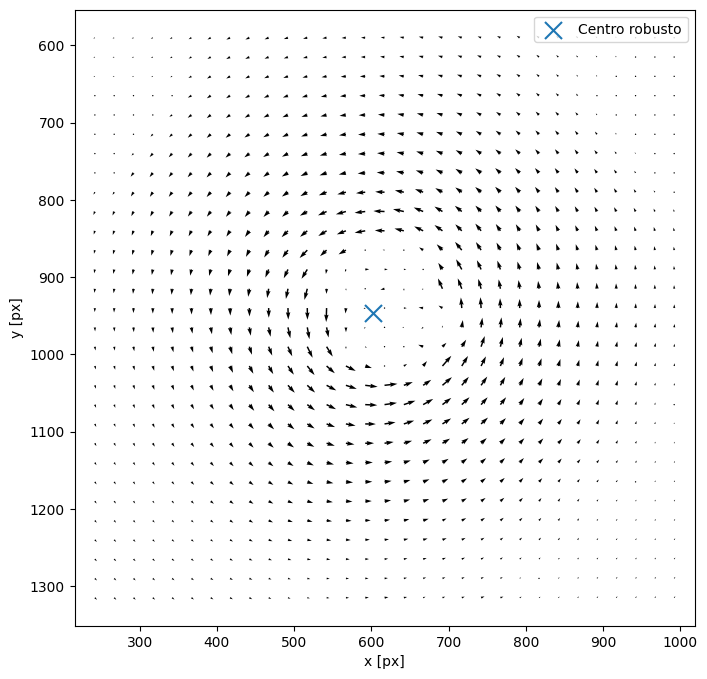

In [18]:
plt.figure(figsize=(8, 8))

plt.quiver(
    x, y, U, V,
    angles="xy",
    scale_units="xy",
    scale=1
)

plt.scatter(
    xc2, yc2,
    marker="x",
    s=150,
    label="Centro robusto"
)

plt.gca().invert_yaxis()
plt.axis("equal")

plt.xlabel("x [px]")
plt.ylabel("y [px]")

plt.legend()
plt.show()

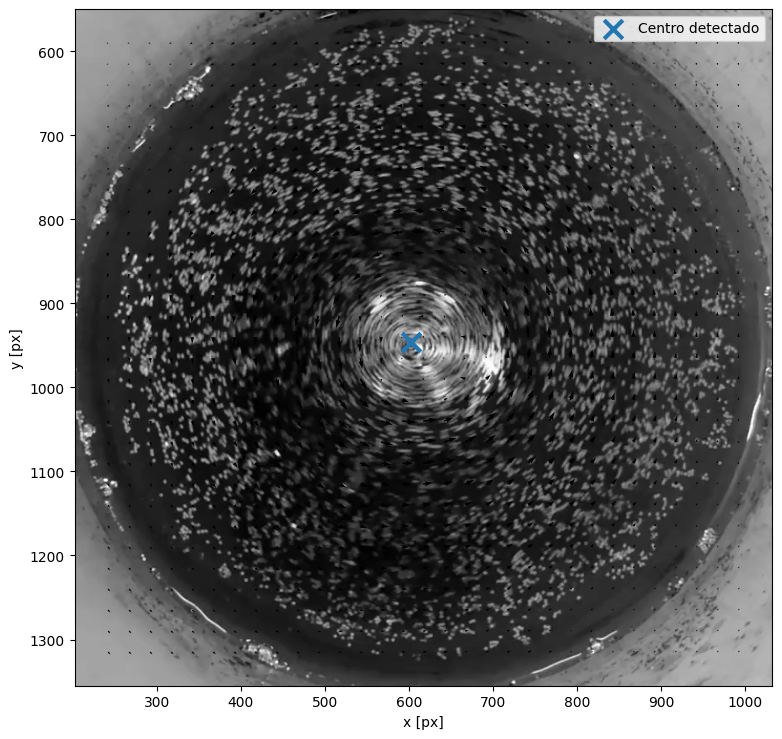

In [19]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

imagen = cv2.imread(
    r"C:\Users\user\Desktop\Labo5\1_Fluidos\analisis\G\frames\frame_0000.png",
    cv2.IMREAD_GRAYSCALE
)

U = u[0]
V = v[0]

plt.figure(figsize=(9, 9))

# Imagen real
plt.imshow(
    imagen,
    cmap="gray",
    origin="upper"
)

# Campo PIV
plt.quiver(
    x,
    y,
    U,
    V,
    angles="xy",
    scale_units="xy",
    scale=1
)

# Centro detectado
plt.scatter(
    xc2,
    yc2,
    marker="x",
    s=180,
    linewidths=3,
    label="Centro detectado"
)

# Mostrar solamente la zona analizada
margen = 40

plt.xlim(
    np.nanmin(x) - margen,
    np.nanmax(x) + margen
)

plt.ylim(
    np.nanmax(y) + margen,
    np.nanmin(y) - margen
)

plt.xlabel("x [px]")
plt.ylabel("y [px]")

plt.legend()
plt.show()

In [25]:
from scipy.optimize import least_squares
import numpy as np

def encontrar_centro(x, y, U, V, centro_aprox=None,
                     rmin=75, rmax=250):

    velocidad = np.sqrt(U**2 + V**2)

    validos = (
        np.isfinite(U)
        & np.isfinite(V)
        & np.isfinite(x)
        & np.isfinite(y)
    )

    # Sacamos vectores de módulo muy chico
    limite = np.nanpercentile(
        velocidad[validos],
        20
    )

    usar = validos & (velocidad > limite)


    # Primera estimación, si no tenemos una previa
    if centro_aprox is None:

        A = np.column_stack([
            U[usar],
            V[usar]
        ])

        b = (
            U[usar] * x[usar]
            + V[usar] * y[usar]
        )

        centro_aprox, _, _, _ = np.linalg.lstsq(
            A,
            b,
            rcond=None
        )


    # Nos quedamos solamente con una corona
    xc0, yc0 = centro_aprox

    r0 = np.sqrt(
        (x - xc0)**2
        + (y - yc0)**2
    )

    usar &= (
        (r0 > rmin)
        & (r0 < rmax)
    )


    X = x[usar]
    Y = y[usar]

    UU = U[usar]
    VV = V[usar]

    M = velocidad[usar]


    def residuos(centro):

        xc, yc = centro

        dx = X - xc
        dy = Y - yc

        r = np.sqrt(dx**2 + dy**2)

        return (
            dx * UU + dy * VV
        ) / (r * M)


    resultado = least_squares(
        residuos,
        x0=centro_aprox,
        loss="soft_l1"
    )

    return resultado.x

In [26]:
centros = np.zeros((len(u), 2))

centro_anterior = None

for i in range(len(u)):

    i0 = max(0, i - 1)
    i1 = min(len(u), i + 2)

    U = np.nanmedian(
        u[i0:i1],
        axis=0
    )

    V = np.nanmedian(
        v[i0:i1],
        axis=0
    )

    centros[i] = encontrar_centro(
        x,
        y,
        U,
        V,
        centro_aprox=centro_anterior,
        rmin=75,
        rmax=250
    )

    centro_anterior = centros[i]


xc_t = centros[:, 0]
yc_t = centros[:, 1]

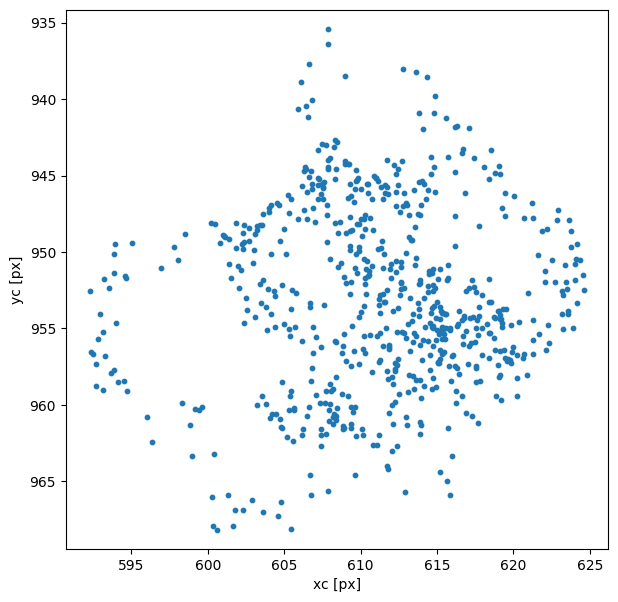

In [27]:
plt.figure(figsize=(7, 7))

plt.scatter(
    xc_t,
    yc_t,
    s=10
)

plt.gca().invert_yaxis()
plt.axis("equal")

plt.xlabel("xc [px]")
plt.ylabel("yc [px]")

plt.show()

In [28]:
saltos = np.sqrt(
    np.diff(xc_t)**2
    + np.diff(yc_t)**2
)

print(
    "Salto mediano:",
    np.median(saltos),
    "px"
)

print(
    "Percentil 95:",
    np.percentile(saltos, 95),
    "px"
)

Salto mediano: 1.187717542362571 px
Percentil 95: 2.881615751892489 px


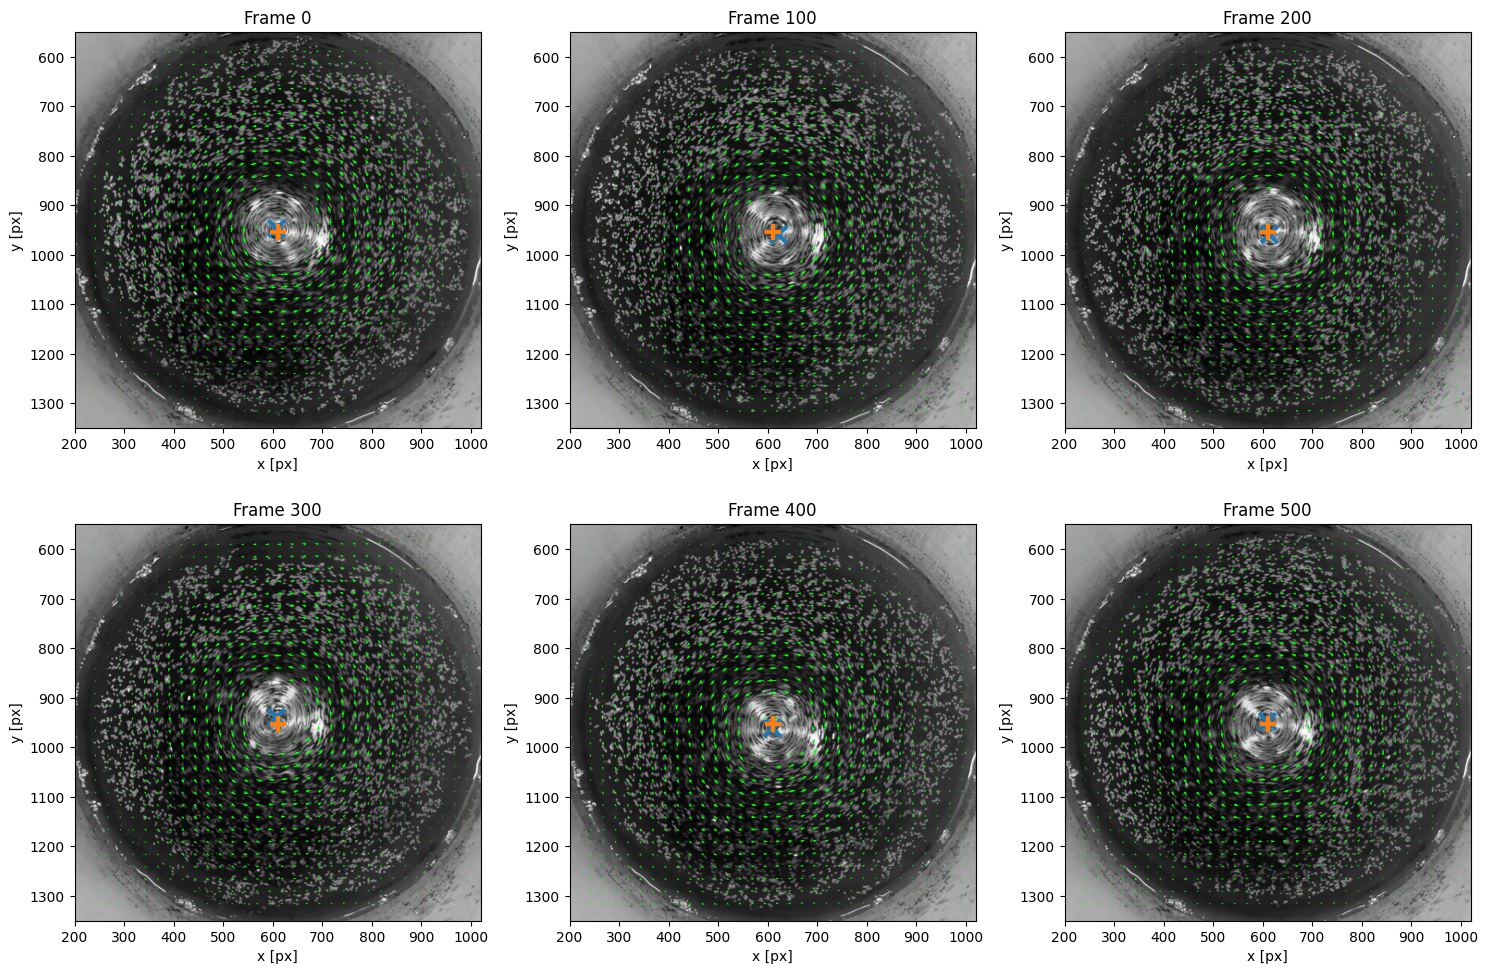

In [30]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

frames_mostrar = [0, 100, 200, 300, 400, 500]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

xc_medio = np.mean(xc_t)
yc_medio = np.mean(yc_t)

for ax, i in zip(axes, frames_mostrar):

    imagen = cv2.imread(
        rf"C:\Users\user\Desktop\Labo5\1_Fluidos\analisis\G\frames\frame_{i:04d}.png",
        cv2.IMREAD_GRAYSCALE
    )

    ax.imshow(
        imagen,
        cmap="gray",
        origin="upper"
    )

    ax.quiver(
        x,
        y,
        u[i],
        v[i],
        angles="xy",
        scale_units="xy",
        scale=1,
        color="lime"
    )

    # centro detectado en ese frame
    ax.scatter(
        xc_t[i],
        yc_t[i],
        marker="x",
        s=140,
        linewidths=3,
        label="centro frame"
    )

    # centro medio total
    ax.scatter(
        xc_medio,
        yc_medio,
        marker="+",
        s=140,
        linewidths=3,
        label="centro medio"
    )

    ax.set_title(f"Frame {i}")
    ax.set_xlim(200, 1020)
    ax.set_ylim(1350, 550)
    ax.set_xlabel("x [px]")
    ax.set_ylabel("y [px]")

plt.tight_layout()
plt.show()

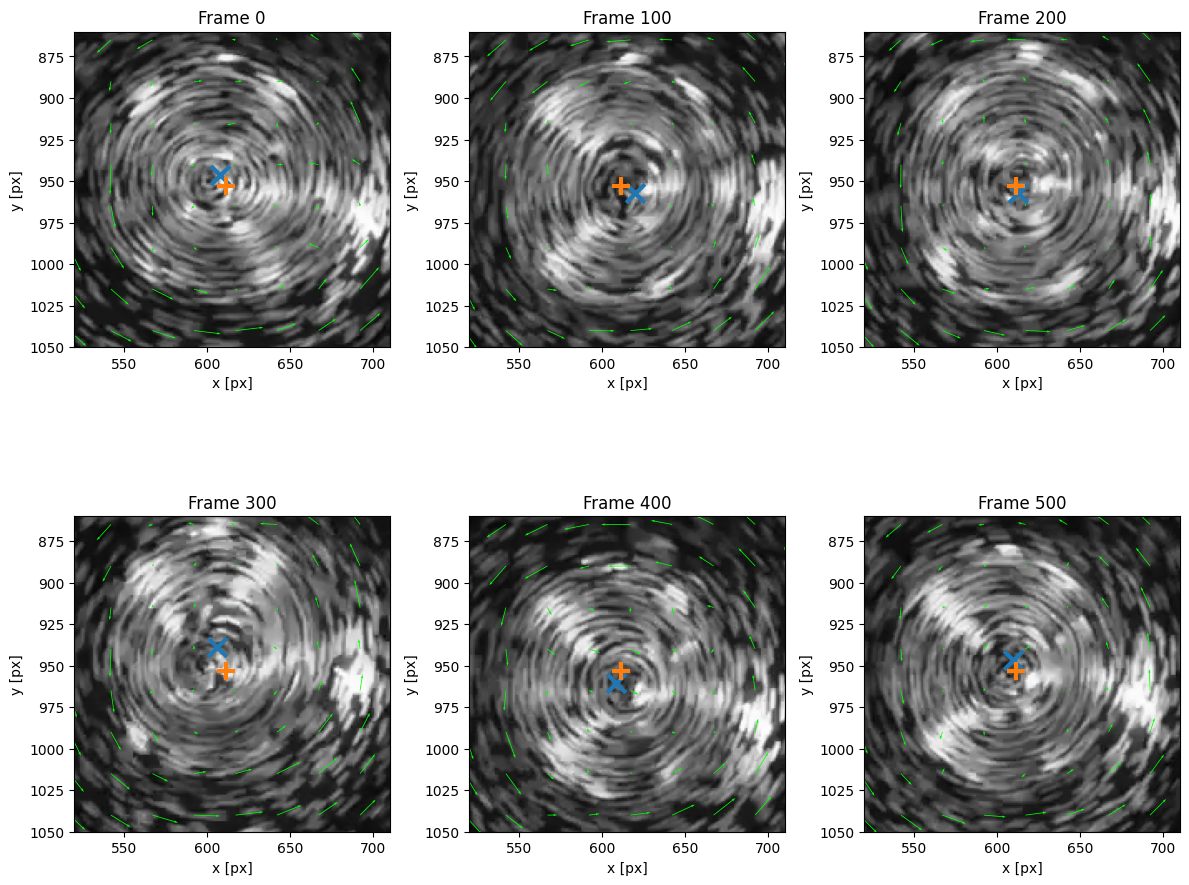

In [31]:
frames_mostrar = [0, 100, 200, 300, 400, 500]

fig, axes = plt.subplots(2, 3, figsize=(12, 10))
axes = axes.ravel()

xc_medio = np.mean(xc_t)
yc_medio = np.mean(yc_t)

for ax, i in zip(axes, frames_mostrar):

    imagen = cv2.imread(
        rf"C:\Users\user\Desktop\Labo5\1_Fluidos\analisis\G\frames\frame_{i:04d}.png",
        cv2.IMREAD_GRAYSCALE
    )

    ax.imshow(imagen, cmap="gray", origin="upper")

    ax.quiver(
        x, y,
        u[i], v[i],
        angles="xy",
        scale_units="xy",
        scale=1,
        color="lime"
    )

    ax.scatter(
        xc_t[i], yc_t[i],
        marker="x",
        s=180,
        linewidths=3,
        label="Centro detectado"
    )

    ax.scatter(
        xc_medio, yc_medio,
        marker="+",
        s=180,
        linewidths=3,
        label="Centro medio"
    )

    # Zoom alrededor del núcleo
    ax.set_xlim(520, 710)
    ax.set_ylim(1050, 860)

    ax.set_title(f"Frame {i}")
    ax.set_xlabel("x [px]")
    ax.set_ylabel("y [px]")

plt.tight_layout()
plt.show()

In [32]:
from scipy.signal import savgol_filter

# Ventana de 31 puntos ≈ 0.52 s a 60 fps
ventana = 31

xc_suave = savgol_filter(
    xc_t,
    window_length=ventana,
    polyorder=2
)

yc_suave = savgol_filter(
    yc_t,
    window_length=ventana,
    polyorder=2
)

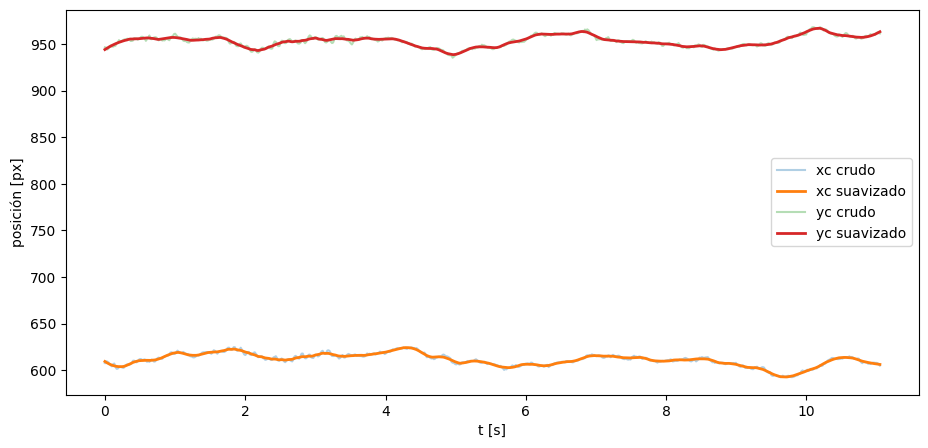

In [33]:
t = np.arange(len(xc_t)) * dt

plt.figure(figsize=(11, 5))

plt.plot(
    t,
    xc_t,
    alpha=0.35,
    label="xc crudo"
)

plt.plot(
    t,
    xc_suave,
    linewidth=2,
    label="xc suavizado"
)

plt.plot(
    t,
    yc_t,
    alpha=0.35,
    label="yc crudo"
)

plt.plot(
    t,
    yc_suave,
    linewidth=2,
    label="yc suavizado"
)

plt.xlabel("t [s]")
plt.ylabel("posición [px]")

plt.legend()
plt.show()

## Perfil radial de velocidades

In [36]:
def componentes_polares(
    x, y, U, V,
    xc, yc,
    mm_por_px,
    dt
):
    """
    Calcula r, v_r y v_theta respecto de un centro (xc, yc).

    x, y, xc, yc están en píxeles.
    U, V están en px/frame.
    """

    # Posición relativa al centro
    dx = x - xc

    # y crece hacia abajo en la imagen:
    # la invertimos para trabajar con eje y físico hacia arriba.
    dy = -(y - yc)

    r_px = np.sqrt(dx**2 + dy**2)

    # Pasamos posiciones a mm
    dx_mm = dx * mm_por_px
    dy_mm = dy * mm_por_px
    r_mm = r_px * mm_por_px

    # Velocidades físicas
    ux = U * mm_por_px / dt
    uy = -V * mm_por_px / dt

    # Evitamos dividir por cero
    er_x = np.divide(
        dx_mm,
        r_mm,
        out=np.full_like(dx_mm, np.nan),
        where=r_mm > 0
    )

    er_y = np.divide(
        dy_mm,
        r_mm,
        out=np.full_like(dy_mm, np.nan),
        where=r_mm > 0
    )

    # Base tangencial
    et_x = -er_y
    et_y = er_x

    # Proyecciones
    vr = ux * er_x + uy * er_y

    vtheta = ux * et_x + uy * et_y

    return r_mm, vr, vtheta

In [37]:
i = 0

r, vr, vtheta = componentes_polares(
    x,
    y,
    u[i],
    v[i],
    xc_t[i],
    yc_t[i],
    mm_por_px,
    dt
)

print("r:", np.nanmin(r), np.nanmax(r), "mm")
print("vr:", np.nanmin(vr), np.nanmax(vr), "mm/s")
print("vtheta:", np.nanmin(vtheta), np.nanmax(vtheta), "mm/s")

r: 1.0959155747314373 50.76319321900668 mm
vr: -37.73247367461833 21.275383293959784 mm/s
vtheta: -28.985953875235243 103.08898057485446 mm/s


In [38]:
dr = 2.5  # mm

r_max = 0.45 * 147  # evitamos llegar pegados a la pared

bins = np.arange(
    0,
    r_max + dr,
    dr
)

r_centros = 0.5 * (
    bins[:-1] + bins[1:]
)

In [39]:
def perfil_radial(r, valor, bins):

    perfil = np.full(
        len(bins) - 1,
        np.nan
    )

    for k in range(len(bins) - 1):

        dentro = (
            (r >= bins[k])
            & (r < bins[k + 1])
            & np.isfinite(valor)
        )

        if np.any(dentro):
            perfil[k] = np.nanmean(
                valor[dentro]
            )

    return perfil

In [40]:
perfiles_theta_movil = []
perfiles_r_movil = []

for i in range(len(u)):

    r, vr, vtheta = componentes_polares(
        x,
        y,
        u[i],
        v[i],
        xc_t[i],
        yc_t[i],
        mm_por_px,
        dt
    )

    perfiles_theta_movil.append(
        perfil_radial(
            r,
            vtheta,
            bins
        )
    )

    perfiles_r_movil.append(
        perfil_radial(
            r,
            vr,
            bins
        )
    )


perfiles_theta_movil = np.array(
    perfiles_theta_movil
)

perfiles_r_movil = np.array(
    perfiles_r_movil
)


vtheta_movil = np.nanmean(
    perfiles_theta_movil,
    axis=0
)

vr_movil = np.nanmean(
    perfiles_r_movil,
    axis=0
)

C:\Users\user\AppData\Local\Temp\ipykernel_23412\1997382264.py:43: RuntimeWarning: Mean of empty slice
  vtheta_movil = np.nanmean(
C:\Users\user\AppData\Local\Temp\ipykernel_23412\1997382264.py:48: RuntimeWarning: Mean of empty slice
  vr_movil = np.nanmean(


In [41]:
xc_fijo = np.mean(xc_t)
yc_fijo = np.mean(yc_t)

perfiles_theta_fijo = []

for i in range(len(u)):

    r, vr, vtheta = componentes_polares(
        x,
        y,
        u[i],
        v[i],
        xc_fijo,
        yc_fijo,
        mm_por_px,
        dt
    )

    perfiles_theta_fijo.append(
        perfil_radial(
            r,
            vtheta,
            bins
        )
    )


perfiles_theta_fijo = np.array(
    perfiles_theta_fijo
)

vtheta_fijo = np.nanmean(
    perfiles_theta_fijo,
    axis=0
)

C:\Users\user\AppData\Local\Temp\ipykernel_23412\901470836.py:32: RuntimeWarning: Mean of empty slice
  vtheta_fijo = np.nanmean(


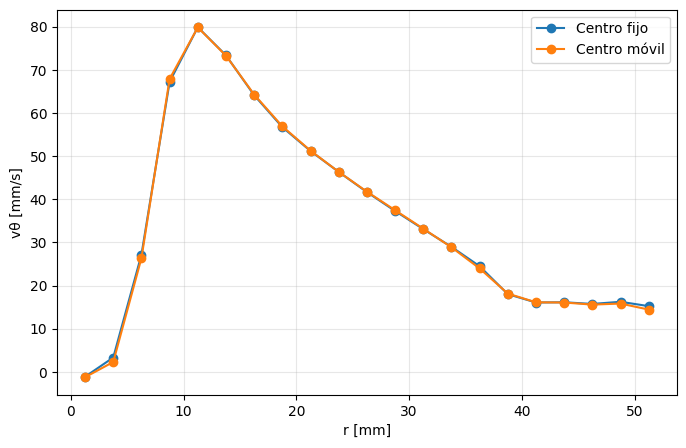

In [42]:
plt.figure(figsize=(8, 5))

plt.plot(
    r_centros,
    vtheta_fijo,
    "o-",
    label="Centro fijo"
)

plt.plot(
    r_centros,
    vtheta_movil,
    "o-",
    label="Centro móvil"
)

plt.xlabel("r [mm]")
plt.ylabel("vθ [mm/s]")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [44]:
perfiles_theta_fijo = []
perfiles_r_fijo = []

for i in range(len(u)):

    r, vr, vtheta = componentes_polares(
        x,
        y,
        u[i],
        v[i],
        xc_fijo,
        yc_fijo,
        mm_por_px,
        dt
    )

    perfiles_theta_fijo.append(
        perfil_radial(r, vtheta, bins)
    )

    perfiles_r_fijo.append(
        perfil_radial(r, vr, bins)
    )


perfiles_theta_fijo = np.array(perfiles_theta_fijo)
perfiles_r_fijo = np.array(perfiles_r_fijo)

vtheta_exp = np.nanmean(
    perfiles_theta_fijo,
    axis=0
)

vr_exp = np.nanmean(
    perfiles_r_fijo,
    axis=0
)

C:\Users\user\AppData\Local\Temp\ipykernel_23412\3882590280.py:29: RuntimeWarning: Mean of empty slice
  vtheta_exp = np.nanmean(
C:\Users\user\AppData\Local\Temp\ipykernel_23412\3882590280.py:34: RuntimeWarning: Mean of empty slice
  vr_exp = np.nanmean(


In [45]:
import numpy as np
from scipy.optimize import curve_fit, least_squares


def rankine_theta(r, C, c):

    r = np.asarray(r, dtype=float)

    return np.where(
        r < c,
        C * r / c**2,
        C / r
    )


def rankine_r(r, C, c):

    return np.zeros_like(
        np.asarray(r, dtype=float)
    )


def burgers_theta(r, C, c):

    r = np.asarray(r, dtype=float)

    return (
        C / r
        * (1 - np.exp(-r**2 / c**2))
    )


def burgers_r(r, c, nu):

    r = np.asarray(r, dtype=float)

    return (
        -2 * nu * r / c**2
    )

In [47]:
nu = 1.0  # mm²/s

In [48]:

valid_theta = (
    np.isfinite(r_centros)
    & np.isfinite(vtheta_exp)
    & (r_centros > 0)
)

r_theta = r_centros[valid_theta]
vt_theta = vtheta_exp[valid_theta]


# Estimaciones iniciales
indice_max = np.argmax(vt_theta)

c0 = r_theta[indice_max]
C0 = vt_theta[indice_max] * c0


popt_rankine, pcov_rankine = curve_fit(
    rankine_theta,
    r_theta,
    vt_theta,
    p0=[C0, c0],
    bounds=(
        [-np.inf, 0.1],
        [np.inf, np.inf]
    )
)

C_rankine, c_rankine = popt_rankine

print("Rankine")
print("C =", C_rankine)
print("c =", c_rankine, "mm")

Rankine
C = 1002.0724411933968
c = 12.447853986846301 mm


In [49]:
valid_theta = (
    np.isfinite(r_centros)
    & np.isfinite(vtheta_exp)
    & (r_centros > 0)
)

valid_r = (
    np.isfinite(r_centros)
    & np.isfinite(vr_exp)
    & (r_centros > 0)
)


r_t = r_centros[valid_theta]
vt = vtheta_exp[valid_theta]

r_r = r_centros[valid_r]
vr = vr_exp[valid_r]

In [50]:
escala_theta = np.nanstd(vt)
escala_r = np.nanstd(vr)

# Evitamos división por cero si vr es casi constante
escala_theta = max(escala_theta, 1.0)
escala_r = max(escala_r, 1.0)

In [51]:
def residuos_burgers(parametros):

    C, c = parametros

    pred_theta = burgers_theta(
        r_t,
        C,
        c
    )

    pred_r = burgers_r(
        r_r,
        c,
        nu
    )

    resid_theta = (
        pred_theta - vt
    ) / escala_theta

    resid_r = (
        pred_r - vr
    ) / escala_r

    return np.concatenate([
        resid_theta,
        resid_r
    ])

In [52]:
resultado_burgers = least_squares(
    residuos_burgers,
    x0=[
        C_rankine,
        c_rankine
    ],
    bounds=(
        [-np.inf, 0.1],
        [np.inf, np.inf]
    )
)

C_burgers, c_burgers = resultado_burgers.x

print("Burgers")
print("C =", C_burgers)
print("c =", c_burgers, "mm")
print("nu =", nu, "mm²/s")

Burgers
C = 1083.2982627497163
c = 11.350946433040727 mm
nu = 1.0 mm²/s


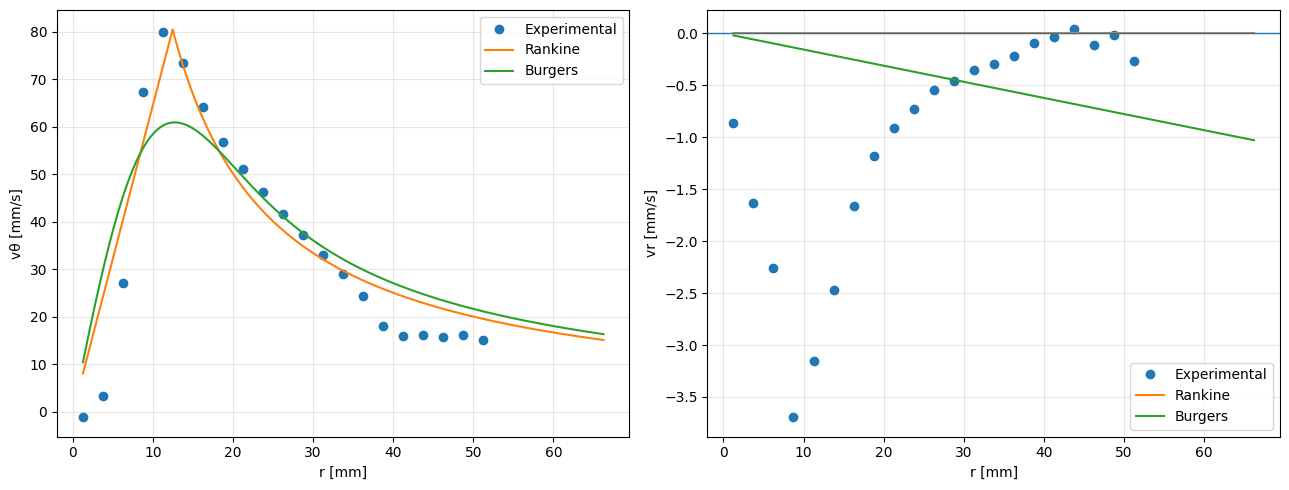

In [53]:
import matplotlib.pyplot as plt

r_continuo = np.linspace(
    np.nanmin(r_centros[r_centros > 0]),
    np.nanmax(r_centros),
    500
)

fig, ax = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)


# ============================
# TANGENCIAL
# ============================

ax[0].plot(
    r_centros,
    vtheta_exp,
    "o",
    label="Experimental"
)

ax[0].plot(
    r_continuo,
    rankine_theta(
        r_continuo,
        C_rankine,
        c_rankine
    ),
    label="Rankine"
)

ax[0].plot(
    r_continuo,
    burgers_theta(
        r_continuo,
        C_burgers,
        c_burgers
    ),
    label="Burgers"
)

ax[0].set_xlabel("r [mm]")
ax[0].set_ylabel("vθ [mm/s]")
ax[0].legend()
ax[0].grid(alpha=0.3)


# ============================
# RADIAL
# ============================

ax[1].plot(
    r_centros,
    vr_exp,
    "o",
    label="Experimental"
)

ax[1].plot(
    r_continuo,
    rankine_r(
        r_continuo,
        C_rankine,
        c_rankine
    ),
    label="Rankine"
)

ax[1].plot(
    r_continuo,
    burgers_r(
        r_continuo,
        c_burgers,
        nu
    ),
    label="Burgers"
)

ax[1].axhline(
    0,
    linewidth=1
)

ax[1].set_xlabel("r [mm]")
ax[1].set_ylabel("vr [mm/s]")
ax[1].legend()
ax[1].grid(alpha=0.3)


plt.tight_layout()
plt.show()